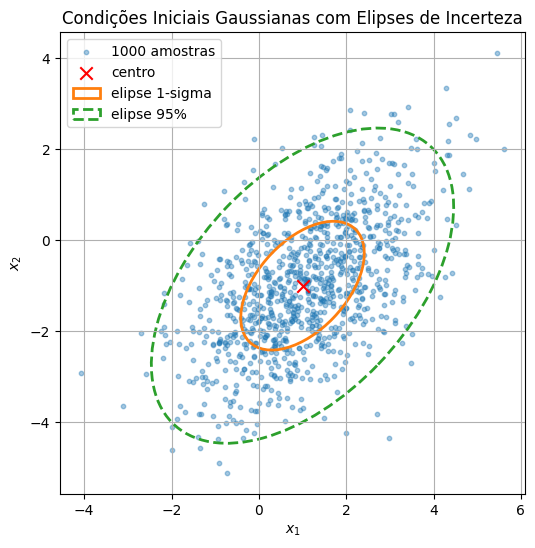

In [6]:
# Sample the initial Gaussian and plot points + uncertainty ellipses
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Parameters
mean = np.array([1.0, -1.0])
P = np.array([[2.0, 1.0],
              [1.0, 2.0]])
N = 1000  # number of sample points
rng = np.random.default_rng(0)

# Draw samples
samples = rng.multivariate_normal(mean, P, size=N)

# Compute eigendecomposition of covariance for ellipse axes
eigvals, eigvecs = np.linalg.eigh(P)  # eigh returns ascending eigenvalues
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Angle of largest principal axis in degrees
angle_rad = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
angle_deg = np.degrees(angle_rad)

# 1-sigma ellipse (semi-axis lengths = sqrt(eigvals))
width_1sigma = 2.0 * np.sqrt(eigvals[0])  # full width = 2*a
height_1sigma = 2.0 * np.sqrt(eigvals[1])

# 95% confidence ellipse for 2D Gaussian:
# factor = sqrt(chi2.ppf(0.95, df=2)) ≈ sqrt(5.991) ≈ 2.4477
from scipy.stats import chi2
factor_95 = np.sqrt(chi2.ppf(0.95, df=2))

width_95 = 2.0 * factor_95 * np.sqrt(eigvals[0])
height_95 = 2.0 * factor_95 * np.sqrt(eigvals[1])

# Plot
mean = tuple(mean)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(samples[:,0], samples[:,1], s=10, alpha=0.4, label=f'{N} amostras')
ax.scatter([mean[0]], [mean[1]], c='red', marker='x', s=80, label='centro')

# Add 1-sigma ellipse
ellipse_1 = Ellipse(xy=mean, width=width_1sigma, height=height_1sigma,
                    angle=angle_deg, edgecolor='C1', facecolor='none',
                    linestyle='-', linewidth=2, label='elipse 1-sigma')
ax.add_patch(ellipse_1)

# Add 95% ellipse
ellipse_95 = Ellipse(xy=mean, width=width_95, height=height_95,
                     angle=angle_deg, edgecolor='C2', facecolor='none',
                     linestyle='--', linewidth=2, label='elipse 95%')
ax.add_patch(ellipse_95)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Condições Iniciais Gaussianas com Elipses de Incerteza')
ax.legend()
ax.grid(True)
plt.show()


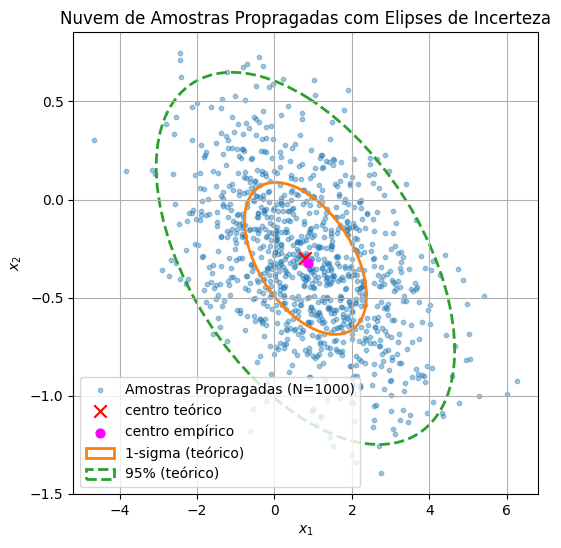

In [7]:
# Propagate samples one step through dynamics with process noise and plot cloud + ellipses

# System matrices
A = np.array([[1.0, 0.2],
              [-0.2, 0.1]])
B = np.array([[0.0],
              [0.3]])
Q = 1.0  # process noise variance

# propagate samples: x_{k+1} = A x_k + B w_k
w = rng.normal(loc=0.0, scale=np.sqrt(Q), size=N)
x_next = samples.dot(A.T) + np.outer(w, B.flatten())

# theoretical propagated mean and covariance
mean_next = A.dot(mean)
P_next = A.dot(P).dot(A.T) + B.dot(B.T) * Q

# empirical mean/covariance from propagated samples
sample_mean = x_next.mean(axis=0)
sample_cov = np.cov(x_next, rowvar=False)

# ellipse helper: eigendecomposition of P_next
eigvals, eigvecs = np.linalg.eigh(P_next)
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
angle_rad = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
angle_deg = np.degrees(angle_rad)

# axis lengths
width_1sigma = 2.0 * np.sqrt(eigvals[0])
height_1sigma = 2.0 * np.sqrt(eigvals[1])

factor_95 = np.sqrt(chi2.ppf(0.95, df=2))

width_95 = 2.0 * factor_95 * np.sqrt(eigvals[0])
height_95 = 2.0 * factor_95 * np.sqrt(eigvals[1])

# Plot
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(x_next[:,0], x_next[:,1], s=10, alpha=0.4, label=f'Amostras Propragadas (N={N})')
ax.scatter([mean_next[0]], [mean_next[1]], c='red', marker='x', s=80, label='centro teórico')
ax.scatter([sample_mean[0]], [sample_mean[1]], c='magenta', marker='o', s=40, label='centro empírico')

ellipse_1 = Ellipse(xy=mean_next, width=width_1sigma, height=height_1sigma,
                    angle=angle_deg, edgecolor='C1', facecolor='none', linewidth=2, label='1-sigma (teórico)')
ax.add_patch(ellipse_1)

ellipse_95 = Ellipse(xy=mean_next, width=width_95, height=height_95,
                     angle=angle_deg, edgecolor='C2', facecolor='none', linestyle='--', linewidth=2, label='95% (teórico)')
ax.add_patch(ellipse_95)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Nuvem de Amostras Propragadas com Elipses de Incerteza')
ax.legend()
ax.grid(True)
plt.show()


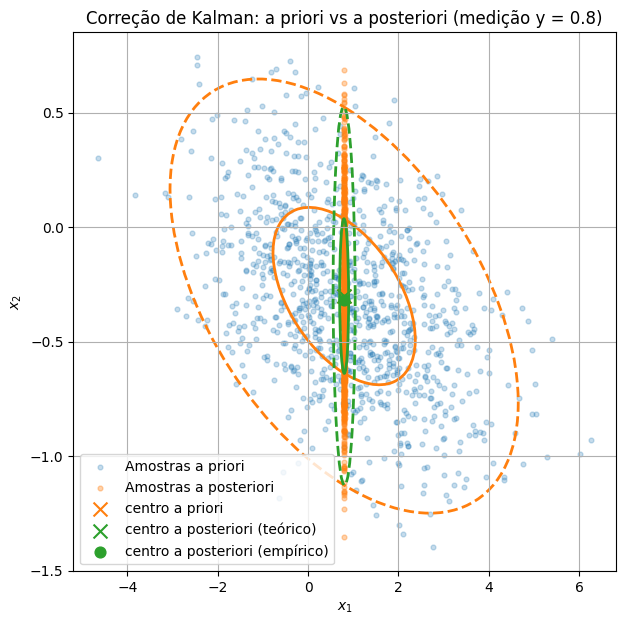

In [8]:
# Kalman correction with measurement y=0.8, update samples and plot prior vs posterior ellipses

# --- Measurement and KF update ---
y_scalar = 0.8                  # using first element of given vector
H = np.array([[1.0, 0.0]])      # measurement matrix (1 x 2)
R = np.array([[0.1**2]])        # measurement variance = 0.01

# Kalman gain (2 x 1)
S = H.dot(P_next).dot(H.T) + R  # innovation covariance (1x1)
K = P_next.dot(H.T).dot(np.linalg.inv(S))

# A posteriori mean and covariance
x_post_mean = mean_next + (K.dot((y_scalar - H.dot(mean_next)).reshape(1,))).flatten()
P_post = (np.eye(2) - K.dot(H)).dot(P_next)

# Apply deterministic analysis update to each sample: x_i^a = x_i^f + K*(y - H x_i^f)
residuals = (y_scalar - x_next.dot(H.T).flatten())   # shape (N,)
x_post_samples = x_next + np.outer(residuals, K.flatten())

# Empirical posterior stats (from updated samples)
emp_post_mean = x_post_samples.mean(axis=0)
emp_post_cov  = np.cov(x_post_samples, rowvar=False)

# --- Ellipse helper (from a covariance) ---
def ellipse_from_cov(mean_pt, cov, nsig=1.0):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle_rad = np.arctan2(eigvecs[1,0], eigvecs[0,0])
    angle_deg = np.degrees(angle_rad)
    width = 2.0 * nsig * np.sqrt(eigvals[0])
    height = 2.0 * nsig * np.sqrt(eigvals[1])
    return Ellipse(xy=mean_pt, width=width, height=height, angle=angle_deg, fill=False, linewidth=2)

# 95% factor for 2D gaussian
factor95 = float(np.sqrt(chi2.ppf(0.95, df=2)))

# --- Plot prior vs posterior ---
fig, ax = plt.subplots(figsize=(7,7))
# prior samples
ax.scatter(x_next[:,0], x_next[:,1], s=12, alpha=0.25, label='Amostras a priori')
# posterior samples
ax.scatter(x_post_samples[:,0], x_post_samples[:,1], s=12, alpha=0.35, label='Amostras a posteriori')

# theoretical prior ellipses
ell_prior_1 = ellipse_from_cov(mean_next, P_next, nsig=1.0)
ell_prior_95 = ellipse_from_cov(mean_next, P_next, nsig=factor95)
ell_prior_1.set_edgecolor('C1'); ell_prior_1.set_linestyle('-')
ell_prior_95.set_edgecolor('C1'); ell_prior_95.set_linestyle('--')
ax.add_patch(ell_prior_1); ax.add_patch(ell_prior_95)

# theoretical posterior ellipses
ell_post_1 = ellipse_from_cov(x_post_mean, P_post, nsig=1.0)
ell_post_95 = ellipse_from_cov(x_post_mean, P_post, nsig=factor95)
ell_post_1.set_edgecolor('C2'); ell_post_1.set_linestyle('-')
ell_post_95.set_edgecolor('C2'); ell_post_95.set_linestyle('--')
ax.add_patch(ell_post_1); ax.add_patch(ell_post_95)

# Mark means
ax.scatter([mean_next[0]], [mean_next[1]], marker='x', c='C1', s=100, label='centro a priori')
ax.scatter([x_post_mean[0]], [x_post_mean[1]], marker='x', c='C2', s=100, label='centro a posteriori (teórico)')
ax.scatter([emp_post_mean[0]], [emp_post_mean[1]], marker='o', c='C2', s=60, label='centro a posteriori (empírico)')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Correção de Kalman: a priori vs a posteriori (medição y = 0.8)')
ax.legend()
ax.grid(True)
plt.show()

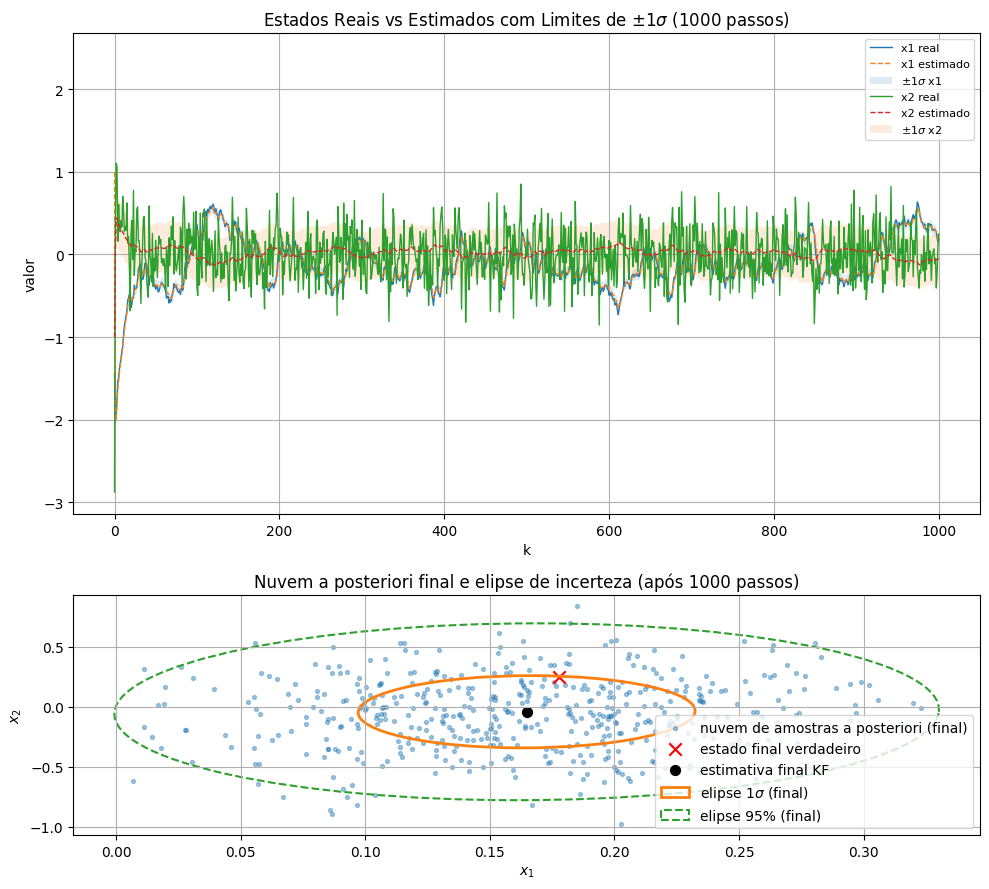

In [13]:
# Simulate one realization, run KF for 1000 steps, and plot results
np.random.seed(0)

# System
A = np.array([[1.0, 0.2],
              [-0.2, 0.1]])
B = np.array([[0.0],
              [0.3]])
H = np.array([[1.0, 0.0]])         # measurement: y = x1 + 0.1*nu
process_noise_var = 1.0            # w_k ~ N(0,1)
meas_noise_std = 0.1               # nu_k std -> R = 0.01

# Initial prior for filter
xbar = np.array([1.0, -1.0])
P0 = np.array([[2.0, 1.0],
               [1.0, 2.0]])

# Simulation settings
Nsteps = 1000

# Draw one true initial state realization
x_true = np.zeros((Nsteps+1, 2))
x_true[0] = np.random.multivariate_normal(xbar, P0)

# Generate process and measurement noise realizations (single-run)
w = np.random.normal(loc=0.0, scale=np.sqrt(process_noise_var), size=Nsteps)
nu = np.random.normal(loc=0.0, scale=meas_noise_std, size=Nsteps)

# Simulate true trajectory and measurements
y = np.zeros(Nsteps)
for k in range(Nsteps):
    x_true[k+1] = A @ x_true[k] + (B.ravel() * w[k])
    y[k] = H.ravel() @ x_true[k+1] + 0.1 * nu[k]   # measurement taken after propagation (y_k ~ x1_k + 0.1*nu)

# Kalman filter initialization (filter knows prior mean & covariance)
x_est = np.zeros((Nsteps+1, 2))
P_est = np.zeros((Nsteps+1, 2, 2))
x_est[0] = xbar.copy()
P_est[0] = P0.copy()

# Run KF (predict then update) for each measurement
R = np.array([[meas_noise_std**2]])  # 0.01
for k in range(Nsteps):
    # Predict
    x_pred = A.dot(x_est[k])
    P_pred = A.dot(P_est[k]).dot(A.T) + B.dot(B.T) * process_noise_var

    # Measurement at step k corresponds to x_true[k+1], y[k] computed above
    S = H.dot(P_pred).dot(H.T) + R             # innovation covariance (1x1)
    K = P_pred.dot(H.T).dot(np.linalg.inv(S))  # Kalman gain (2x1)

    innov = (y[k] - H.dot(x_pred)).reshape(1,)
    x_upd = x_pred + (K.dot(innov)).flatten()
    P_upd = (np.eye(2) - K.dot(H)).dot(P_pred)

    # store
    x_est[k+1] = x_upd
    P_est[k+1] = P_upd

# Compute estimation errors and 1-sigma bounds
err = x_true - x_est
sigma1 = np.sqrt(P_est[:, [0,1], [0,1]])   # shape (Nsteps+1, 2) diag elements sqrt

# Plotting: time series and final ellipse
fig, axes = plt.subplots(2, 1, figsize=(10,9), gridspec_kw={'height_ratios':[2,1]})
t = np.arange(Nsteps+1)

# Top: state components true vs estimate with ±1σ
for i in range(2):
    ax = axes[0]
    ax.plot(t, x_true[:, i], label=f'x{i+1} real' if i==0 else None, linewidth=1)
    ax.plot(t, x_est[:, i], linestyle='--', label=f'est x{i+1}' if i==0 else None, linewidth=1)
    ax.fill_between(t,
                    x_est[:, i] - sigma1[:, i],
                    x_est[:, i] + sigma1[:, i],
                    alpha=0.15,
                    label=f'$±1\\sigma$ x{i+1}' if i==0 else None)
# Make clearer labels: plot both components in two different colors
axes[0].plot([],[],color='C0',label='x1 real'); axes[0].plot([],[],color='C1',label='x2 real')
axes[0].legend(['x1 real','x1 estimado','$±1\\sigma$ x1','x2 real','x2 estimado','$±1\\sigma$ x2'], loc='upper right', fontsize=8)
axes[0].set_xlabel('k')
axes[0].set_ylabel('valor')
axes[0].set_title('Estados Reais vs Estimados com Limites de $±1\\sigma$ (1000 passos)')
axes[0].grid(True)

# Bottom: final-state scatter for small Monte Carlo around final estimate to visualize ellipse
# Create small cloud by drawing samples from final posterior Gaussian
final_mean = x_est[-1]
final_P = P_est[-1]
Mcloud = 500
cloud = np.random.multivariate_normal(final_mean, final_P, size=Mcloud)

ax2 = axes[1]
ax2.scatter(cloud[:,0], cloud[:,1], s=8, alpha=0.4, label='nuvem de amostras a posteriori (final)')
ax2.scatter([x_true[-1,0]], [x_true[-1,1]], c='red', marker='x', s=80, label='estado final verdadeiro')
ax2.scatter([final_mean[0]], [final_mean[1]], c='black', marker='o', s=50, label='estimativa final KF')

# draw 1-sigma ellipse for final posterior
eigvals, eigvecs = np.linalg.eigh(final_P)
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))
width = 2.0 * np.sqrt(eigvals[0])
height = 2.0 * np.sqrt(eigvals[1])
ell = Ellipse(xy=final_mean, width=width, height=height, angle=angle, edgecolor='C1', facecolor='none', linewidth=2, label='elipse $1 \\sigma$ (final)')
ax2.add_patch(ell)

# 95% ellipse
from math import sqrt
chi2_95 = 5.991  # chi2.ppf(0.95, df=2)
factor95 = sqrt(chi2_95)
ell95 = Ellipse(xy=final_mean, width=2*factor95*np.sqrt(eigvals[0]), height=2*factor95*np.sqrt(eigvals[1]), angle=angle, edgecolor='C2', facecolor='none', linestyle='--', linewidth=1.5, label='elipse 95% (final)')
ax2.add_patch(ell95)

ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Nuvem a posteriori final e elipse de incerteza (após 1000 passos)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()